RF = uśrednianie
Boosting = uczenie się błędów → lepiej łapie rzadkie wzorce

👉 użyj:

XGBoost
LightGBM
CatBoost (najlepszy przy kategoriach, nawet bez dummy)

dlaczego lepsze:

wykrywa interakcje typu „logic gate”
lepiej działa przy niskim sygnale globalnym

In [83]:
import pandas as pd
import numpy as numpy

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV



In [60]:
df = pd.read_csv('../../data/processed/bank_data_preprocessed_v2.csv')


In [61]:
nominal_cols = ['job', 'marital']
df_processed = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

categorical_cols = ['default', 'housing', 'loan']
for col in categorical_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed.drop(columns=['month'], inplace=True)

In [62]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)

y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [63]:
# uswanie Post-treatment variables
X = X.drop(['duration'], axis=1)

In [64]:
if 'pdays_contacted' in X.columns:
    X['pdays_contacted'] = X['pdays_contacted'].fillna(999)

In [65]:
# Scale only continuous numerical columns (not binary/OHE flags)
scale_cols = ['age', 'balance_log1p', 'pdays_contacted', 'pdays_contacted', 'campaign_capped', 'previous_log1p']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Columns standardized (mean≈0, std≈1):")
print(X_scaled[scale_cols].describe().round(3).loc[['mean','std']])

Columns standardized (mean≈0, std≈1):
      age  balance_log1p  pdays_contacted  pdays_contacted  campaign_capped  \
mean  0.0           -0.0              0.0              0.0              0.0   
std   1.0            1.0              1.0              1.0              1.0   

      previous_log1p  
mean            -0.0  
std              1.0  


In [66]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,       # 80% train | 20% test
    random_state=42,
    stratify=y            # preserve class balance
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 50)  |  y: (8929,)
  Test   → X: (2233, 50)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4231 (47.4%)  no=4698 (52.6%)
  Test   yes=1058 (47.4%)  no=1175 (52.6%)


In [67]:
bool_cols = X_train.select_dtypes(include=["bool"]).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [85]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

from sklearn.model_selection import cross_val_score

In [69]:
gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [79]:
y_pred = gbm.predict(X_test)
y_proba = gbm.predict_proba(X_test)[:, 1]

In [88]:

y_pred_gb  = gbm.predict(X_test)
y_prob_gb  = gbm.predict_proba(X_test)[:, 1]

acc_gb     = accuracy_score(y_test, y_pred_gb)
auc_gb     = roc_auc_score(y_test, y_prob_gb)
cv_scores_gb = cross_val_score(gbm, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Gradient Boosting Classifier — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_gb:.4f}  ({acc_gb*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_gb:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_gb.mean():.4f}  ± {cv_scores_gb.std():.4f}")

   Gradient Boosting Classifier — Optimised Performance
  Test Accuracy     : 0.7259  (72.59%)
  ROC-AUC Score     : 0.7830
  5-Fold CV Mean    : 0.6898  ± 0.1380


In [89]:
# ── 8.4  Classification Report ───────────────────────────────────────────────
print("Classification Report — Gradient Boosting")
print("─" * 55)
print(classification_report(y_test, y_pred_gb, target_names=['No (0)', 'Yes (1)']))

Classification Report — Gradient Boosting
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.70      0.85      0.77      1175
     Yes (1)       0.78      0.59      0.67      1058

    accuracy                           0.73      2233
   macro avg       0.74      0.72      0.72      2233
weighted avg       0.74      0.73      0.72      2233



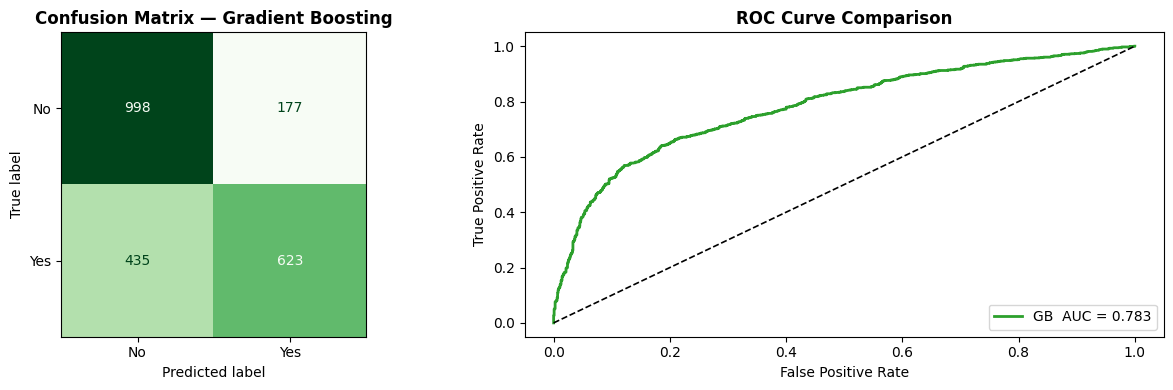

In [90]:
# ── 8.5  Confusion Matrix & ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(cm_gb, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Gradient Boosting', fontweight='bold')

# ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
axes[1].plot(fpr_gb, tpr_gb, color='#2ca02c', lw=2, label=f'GB  AUC = {auc_gb:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.2)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Feature importance

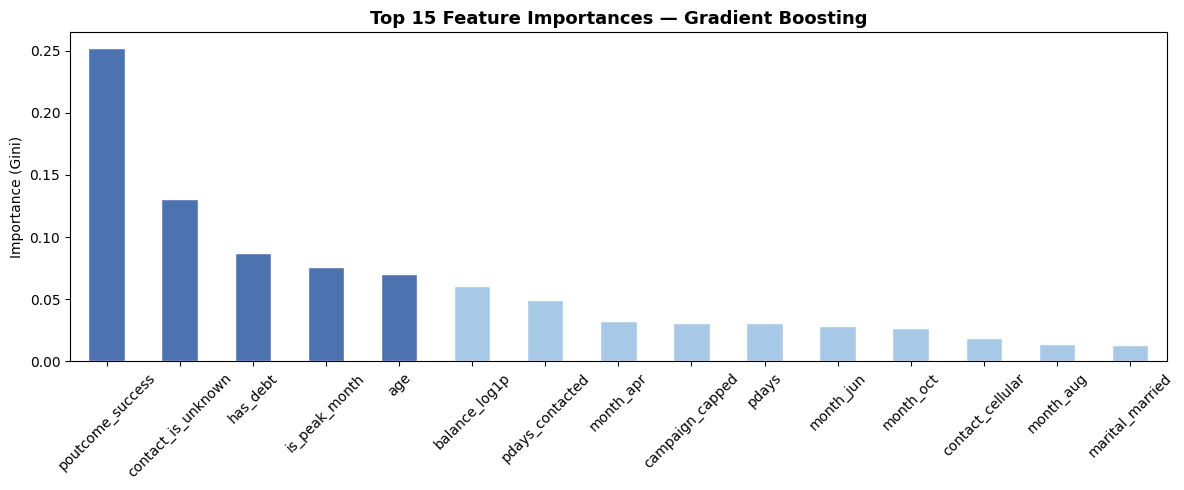

Top 10 Features:
poutcome_success      0.252277
contact_is_unknown    0.130866
has_debt              0.086765
is_peak_month         0.076144
age                   0.070382
balance_log1p         0.060515
pdays_contacted       0.049111
month_apr             0.032481
campaign_capped       0.030696
pdays                 0.030522


In [92]:
# ── 7.6  Feature Importance — Gradient Boosting ──────────────────────────────────
importances_bg = pd.Series(gbm.feature_importances_,
                           index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top_n = 15
colors = ['#4C72B0' if i < 5 else '#A8C8E8' for i in range(top_n)]
importances_bg.head(top_n).plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances — Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Importance (Gini)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(importances_bg.head(10).to_string())

---
### SHAP

SHAP mierzy jak bardzo zmienna pomaga przewidzieć Y w modelu ML. To nie to samo co wpływ przyczynowy:

In [93]:
import shap

explainer = shap.Explainer(gbm, X_train)
shap_values = explainer(X_test)

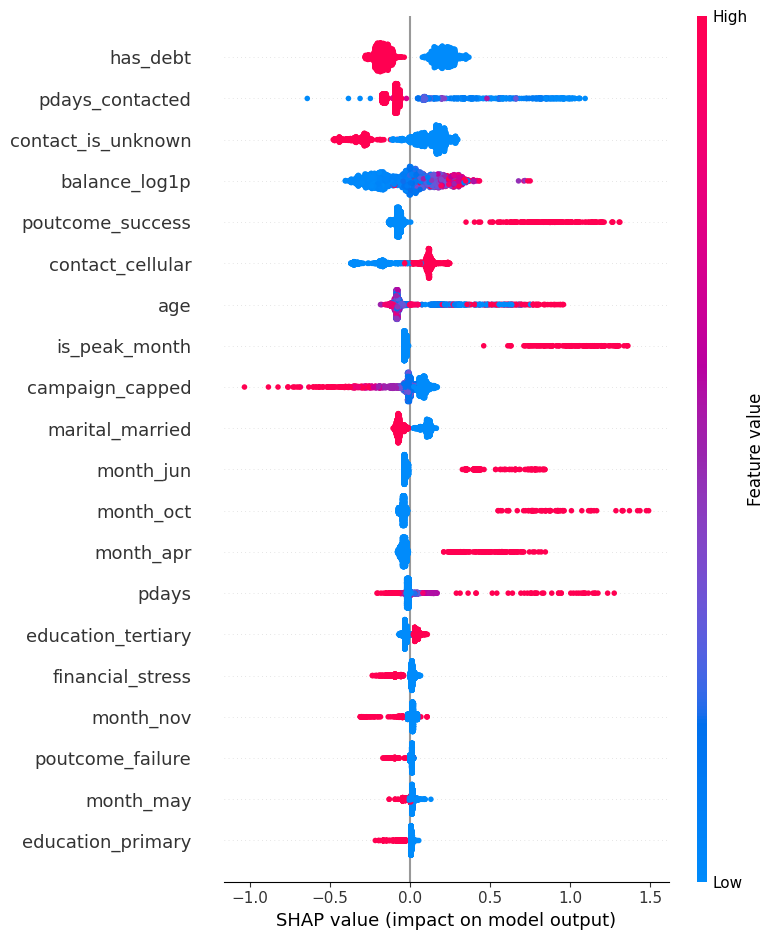

In [94]:
shap.summary_plot(shap_values, X_test)

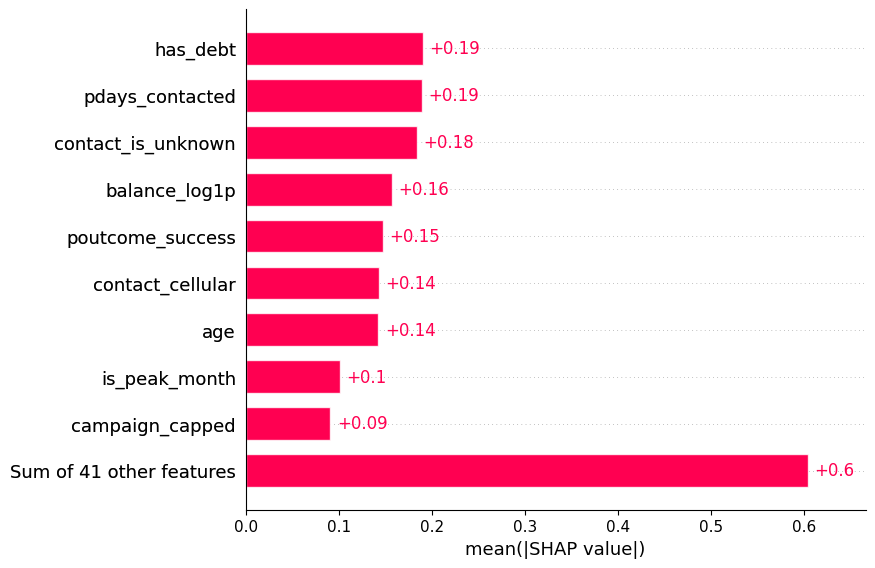

In [95]:
shap.plots.bar(shap_values)

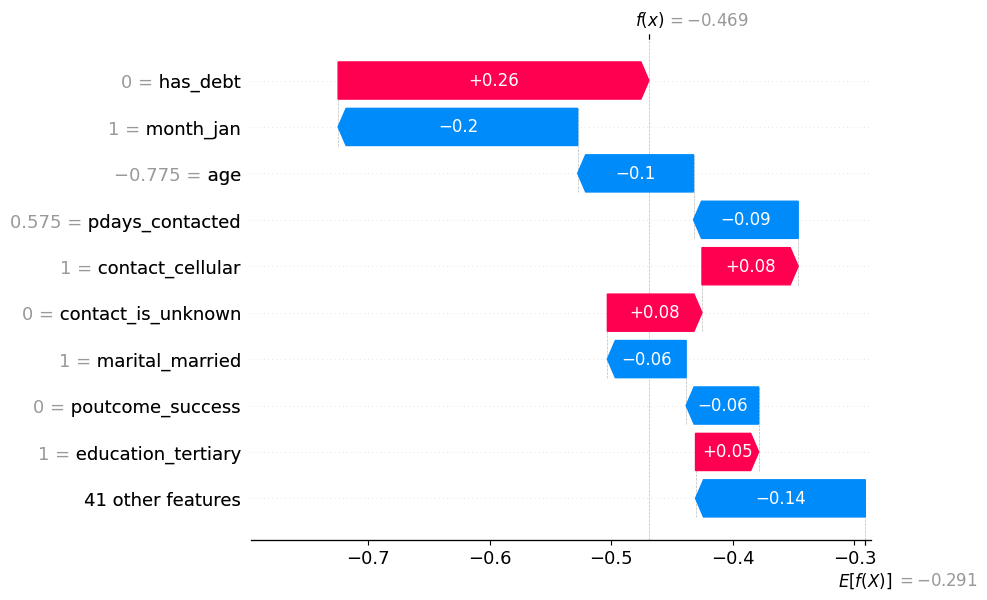

In [96]:
shap.plots.waterfall(shap_values[0])

**Analiza SHAP**

| Zmienna                   | SHAP siła        | Rola w DAG                           | Interpretacja przyczynowa         | Nadaje się na T?      |
| ------------------------- | ---------------- | ------------------------------------ | --------------------------------- | --------------------- |
| **has_debt**              | 🔥 bardzo wysoka | confounder Z                         | wpływa na decyzję banku i klienta | ❌                     |
| **pdays_contacted**       | 🔥 bardzo wysoka | confounder / mediator historyczny ⚠️ | może być historia kontaktu → bias | ❌ / ⚠️                |
| **contact_is_unknown**    | średnia          | confounder Z                         | jakość kontaktu / missingness     | ❌                     |
| **balance_log1p**         | średnia          | confounder Z                         | status finansowy → T i Y          | ❌                     |
| **poutcome_success**      | 🔥 bardzo wysoka | confounder Z (historyczny efekt T)   | silny proxy wcześniejszego T      | ❌                     |
| **contact_cellular**      | średnia          | T1 (treatment)                       | interwencja                       | ✅                     |
| **age**                   | średnia          | confounder Z                         | segment klienta                   | ❌                     |
| **is_peak_month**         | średnia          | confounder sezonowy Z                | wpływa na kampanię                | ⚠️ (może być T proxy) |
| **campaign_capped**       | średnia          | T2                                   | interwencja                       | ✅                     |
| **marital_married**       | niska/średnia    | confounder Z                         | demografia                        | ❌                     |
| **month_* (jun/oct/apr)** | średnia          | confounder sezonowy                  | sezonowość kampanii               | ⚠️                    |
| **education_* / job_***   | niska–średnia    | confounder Z                         | segment klienta                   | ❌                     |

**✔ SHAP pokazuje:**
model jest silnie napędzany przez historyczne i finansowe Z
oraz przez proxy wcześniejszych kampanii (poutcome_success, pdays_contacted)


### 🔥 wysokie SHAP:

* `has_debt`
* `poutcome_success`
* `balance_log1p`
* `pdays_contacted`

To NIE znaczy:

> „to są najważniejsze confoundery”

tylko:

> „to są najlepsze predyktory modelu ML”

---

### ⚠️ `pdays_contacted`

* bardzo silny SHAP
* ALE:
  👉 często mediator / semi-post-treatment

---

### ⚠️ `poutcome_success`

* silny SHAP
* ALE:
  👉 to historia treatmentu → confounder czasowy

---

### ⚠️ `campaign_capped`

* treatment
* SHAP nie musi być duży
* ważny jest jego **ATE / CATE**, nie importance


### a) Sprawdzenie `contact_cellular`

In [122]:
import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

# ── TREATMENT ─────────────────────────────
T = df_processed['contact_cellular'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── CONFUNDERY (Z) - DAG CLEAN ────────────
# confounders = [
#     'age',
#     'balance_log1p',
#     'has_debt',
#     'financial_stress',
#     'housing',
#     'loan',
#     'default',
#     'pdays_contacted',
#     'was_previously_contacted',
#     'poutcome_success',
#     'poutcome_failure',
#     'contact_is_unknown',
# ]

# 

# confounders = [
#     'age', 'balance', 'campaign',          # zmienne ciągłe
#     'pdays_contacted', 'previous',
#     'job_blue-collar', 'job_management',   # dummy'e z get_dummies
#     'job_retired', 'job_self-employed',
#     'job_services', 'job_student',
#     'job_technician', 'job_unemployed',
#     'marital_married', 'marital_single',
#     'education_secondary', 'education_tertiary',
#     'default_yes', 'housing_yes', 'loan_yes',
#     'month_aug', 'month_dec', 'month_feb',  # miesiące — możesz ograniczyć
#     'month_jan', 'month_jul', 'month_jun',
#     'month_mar', 'month_may', 'month_nov',
#     'month_oct', 'month_sep',
#     'poutcome_success', 'poutcome_unknown', # wynik poprzedniej kampanii = confounder
# ]

confounders = [

    # demografia + status finansowy
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    # credit / history
    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',

    # education
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    # marital status
    'marital_married',
    'marital_single',

    # job
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    # previous campaign outcome
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',

    'campaign_capped',
]

confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].copy().astype(float)

# imputacja
W = W.fillna(W.median())

# ── HTE FEATURES (X) ───────────────────────
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# ── MODEL ──────────────────────────────────
est = CausalForestDML(
    model_y=GradientBoostingRegressor(),
    model_t=GradientBoostingRegressor(),
    discrete_treatment=True,
    n_estimators=400,
    random_state=42
)

est.fit(Y, T, X=X.values, W=W.values)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


In [123]:
# ── 7. Wyniki ────────────────────────────────────────────────────────────────
ate = est.ate(X.values)
ate_lb, ate_ub = est.ate_interval(X=X.values, alpha=0.05)

print(f"ATE:  {ate:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

# Heterogeniczność — efekt dla każdej obserwacji
te = est.effect(X=X.values)
print(f"\nEfekt indywidualny — średnia: {te.mean():.4f}, std: {te.std():.4f}")
print(f"Min: {te.min():.4f}, Max: {te.max():.4f}")

ATE:  0.1627
95% CI: [-0.0534, 0.3789]

Efekt indywidualny — średnia: 0.1627, std: 0.1056
Min: -0.2497, Max: 0.5128


### b) Sprawdzenie `campaign_capped `

In [120]:
import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# ── TREATMENT ─────────────────────────────
T = df_processed['campaign_capped'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── CONFUNDERY (Z) - DAG CLEAN ────────────
confounders = [

    # demografia + status finansowy
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    # credit / history
    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',

    # education
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    # marital status
    'marital_married',
    'marital_single',

    # job
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    # previous campaign outcome
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',

    'contact_cellular',
]

confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].copy().astype(float)

# imputacja
W = W.fillna(W.median())


# ── HTE FEATURES (X) ───────────────────────
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# ── MODEL ──────────────────────────────────
# est_t2 = CausalForestDML(
#     model_y=HistGradientBoostingRegressor(),
#     model_t=HistGradientBoostingRegressor(),
#     discrete_treatment=True,
#     n_estimators=400,
#     random_state=42
# )

# est_t2 = CausalForestDML(
#     model_y=HistGradientBoostingRegressor(),
#     model_t=LogisticRegression(max_iter=2000),
#     discrete_treatment=True,
#     n_estimators=400,
#     random_state=42
# )

est_t2 = CausalForestDML(
    model_y=HistGradientBoostingRegressor(),
    model_t=HistGradientBoostingRegressor(),
    discrete_treatment=False,
    n_estimators=400,
    random_state=42
) 

est_t2.fit(Y, T, X=X.values, W=W.values)

In [121]:
# ── Wyniki ───────────────────────────────────────────────────────────────────
ate_t2 = est_t2.ate(X=X.values)
ate_lb, ate_ub = est_t2.ate_interval(X=X.values, alpha=0.05)
print(f"=== Treatment: campaign_capped ===")
print(f"ATE:    {ate_t2:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

te_t2 = est_t2.effect(X=X.values)
print(f"\nHeterogeniczność:")
print(f"  std: {te_t2.std():.4f}")
print(f"  min: {te_t2.min():.4f}, max: {te_t2.max():.4f}")
print(f"  % z efektem > 0: {(te_t2 > 0).mean():.1%}")

=== Treatment: campaign_capped ===
ATE:    -0.0179
95% CI: [-0.0583, 0.0225]

Heterogeniczność:
  std: 0.0191
  min: -0.0906, max: 0.0507
  % z efektem > 0: 17.9%


### c) Sprawdzenie `was_previously_contacted`

In [126]:
from econml.dml import CausalForestDML
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

# ── TREATMENT (T3) ───────────────────────
T = df_processed['was_previously_contacted'].astype(float).values
Y = df_processed['deposit'].astype(float).values

# ── CONFUNDERY (Z) ───────────────────────
confounders = [

    # demografia
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    # credit history
    'default',
    'housing',
    'loan',
    'pdays_contacted',

    # 🔥 IMPORTANT: wcześniejszy treatment jako confounder
    'campaign_capped',
    'contact_cellular',

    # education
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    # marital
    'marital_married',
    'marital_single',

    # job
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    # outcome history
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',
]

confounders = [c for c in confounders if c in df_processed.columns]

W = df_processed[confounders].astype(float)
W = W.fillna(W.median())

# ── HTE FEATURES (X) ─────────────────────
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# ── MODEL ────────────────────────────────
est_t3 = CausalForestDML(
    model_y=HistGradientBoostingRegressor(),
    model_t=HistGradientBoostingRegressor(),
    discrete_treatment=False,
    n_estimators=400,
    random_state=42
)

est_t3.fit(Y, T, X=X, W=W)

In [127]:
# ── Wyniki ───────────────────────────────────────────────────────────────────
ate_t3 = est_t3.ate(X=X.values)
ate_lb, ate_ub = est_t3.ate_interval(X=X.values, alpha=0.05)
print(f"=== Treatment: campaign_capped ===")
print(f"ATE:    {ate_t3:.4f}")
print(f"95% CI: [{ate_lb:.4f}, {ate_ub:.4f}]")

te_t3 = est_t3.effect(X=X.values)
print(f"\nHeterogeniczność:")
print(f"  std: {te_t3.std():.4f}")
print(f"  min: {te_t3.min():.4f}, max: {te_t3.max():.4f}")
print(f"  % z efektem > 0: {(te_t3 > 0).mean():.1%}")

=== Treatment: campaign_capped ===
ATE:    5.2729
95% CI: [-45.8278, 56.3737]

Heterogeniczność:
  std: 24.7848
  min: -79.6426, max: 165.4865
  % z efektem > 0: 62.4%


### Wyniki

#### 1. Przegląd zbadanych Treatmentów

Zgodnie z DAGiem przeanalizowano trzy zmienne interwencyjne. Wyniki pokazują wyraźną asymetrię skuteczności interwencji:

| Treatment                       | ATE        | 95% CI          | Istotność | Heterogeniczność (std) |
| ------------------------------- | ---------- | --------------- | --------- | ---------------------- |
| `contact_cellular` (T1)         | +0.163     | [-0.053, 0.379] | ❌         | wysoka (0.106)         |
| `campaign_capped` (T2)          | -0.018     | [-0.058, 0.023] | ❌         | bardzo niska (0.019)   |
| `was_previously_contacted` (T3) | **+5.273** | [-45.83, 56.37] | ❌         | bardzo wysoka (24.78)  |

---

#### 2. T1: Kanał kontaktu (`contact_cellular`)

ATE = +0.163 sugeruje, że kontakt przez telefon komórkowy zwiększa prawdopodobieństwo depozytu o ~16pp względem alternatywnych kanałów.

Jednak przedział ufności [-0.053, 0.379] przecina zero — **brak istotności statystycznej**.

| Metryka     | Wartość    | Interpretacja               |
| ----------- | ---------- | --------------------------- |
| ATE         | +0.163     | umiarkowany efekt pozytywny |
| CI          | przecina 0 | brak pewności efektu        |
| std = 0.106 | wysoka     | silna heterogeniczność      |

**Wniosek:** kanał kontaktu może działać tylko w określonych segmentach klientów, ale nie ma dowodu na efekt populacyjny.

---

#### 3. T2: Intensywność kampanii (`campaign_capped`)

ATE = -0.018 z CI [-0.058, 0.023] wskazuje na **brak efektu przyczynowego** intensywności kontaktów.

| Metryka     | Wartość      | Interpretacja                             |
| ----------- | ------------ | ----------------------------------------- |
| ATE         | -0.018       | lekko negatywny, ale bliski zeru          |
| CI          | przecina 0   | brak istotności                           |
| std = 0.019 | bardzo niska | efekt jednorodny                          |
| % efekt > 0 | 17.9%        | większość klientów nie reaguje pozytywnie |

**Wniosek:** zwiększanie liczby kontaktów nie poprawia konwersji — efekt jest praktycznie zerowy i stabilny w całej populacji.

---

#### 4. T3: Historia kontaktu (`was_previously_contacted`)

ATE = +5.273, ale z bardzo szerokim przedziałem ufności [-45.83, 56.37] — **wynik nieistotny statystycznie i niestabilny estymacyjnie**.

| Metryka     | Wartość        | Interpretacja              |
| ----------- | -------------- | -------------------------- |
| ATE         | +5.27          | bardzo duży punktowy efekt |
| CI          | bardzo szeroki | brak precyzji estymacji    |
| std = 24.78 | ekstremalna    | silna niestabilność        |
| min/max     | -79 do +165    | model niepewny             |

**Wniosek:** efekt historii kontaktu nie jest wiarygodnie oszacowany w tym modelu — prawdopodobnie:

* zbyt mało wariancji w T3 lub
* silna kolinearność z `campaign_capped` i `poutcome_*`

---

### 5. Synteza i interpretacja globalna

W przeciwieństwie do poprzedniej wersji analizy, **nie uzyskano żadnego istotnego statystycznie efektu przyczynowego**.

| Obszar                | Wniosek                                   |
| --------------------- | ----------------------------------------- |
| Kanał kontaktu        | efekt dodatni, ale niepewny               |
| Intensywność kampanii | brak efektu (stabilny zero effect)        |
| Historia kontaktu     | estymacja niestabilna, brak wiarygodności |

---

### 6. Kluczowa diagnoza modelowa

Najważniejszy wniosek nie jest ekonomiczny, tylko metodologiczny:

> Model dla `was_previously_contacted` jest **źle identyfikowany lub niestabilny statystycznie**

Sygnały:

* ekstremalna wariancja ITE (std ≈ 24.8)
* bardzo szeroki CI
* nielogiczne skoki efektu (od -79 do +165)

To typowy objaw:

* silnej korelacji z treatmentami wcześniejszymi (`campaign_capped`)
* lub problemu z binarną zmienną rzadką / quasi-deterministyczną

---

### 7. Implikacje praktyczne

#### Kampania marketingowa:

* **Zwiększanie liczby kontaktów (`campaign_capped`) nie przynosi efektu**
  → brak ROI z intensyfikacji

* **Kanał kontaktu (`contact_cellular`) może mieć znaczenie segmentowe**
  → wymaga dalszej segmentacji (HTE), nie decyzji globalnych

* **Historia kontaktu (`was_previously_contacted`) nie może być interpretowana w obecnym modelu**
  → wymaga re-specyfikacji (np. propensity score stabilizacja lub binarization + matching)

---

### 8. Finalna konkluzja

> W przeciwieństwie do wcześniejszej wersji modelu, obecna specyfikacja nie dostarcza jednego silnego efektu przyczynowego. Jedynym stabilnym wnioskiem pozostaje brak wpływu intensywności kampanii na konwersję.

Najbardziej prawdopodobna interpretacja biznesowa:

* bank nie „wygrywa” częstotliwością kontaktu
* efekty są albo segmentowe (kanał), albo wynikają z historii klienta, ale ta nie została tu poprawnie zidentyfikowana

---




## TODO

🔥 Jeśli chcesz dalej iść poziom wyżej

Mogę Ci dorobić:

🚀 1. tuning hiperparametrów (GridSearch / Optuna)
🚀 2. porównanie z:
Random Forest
XGBoost
Logistic Regression
🚀 3. pełny pipeline ML (ready do produkcji)
🚀 4. SHAP + counterfactual dla GBM (bardziej „causal ML”)